In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

base_dir = "/Users/theabood/Desktop/DataScience/semester3/Datasets/products/train"

1. Class Distribution Analysis

Identifies the number of samples per class to detect dataset imbalance. This is crucial as imbalance can bias models and distort metrics like accuracy and F1-score.


 1. CLASS DISTRIBUTION
            Class  Image_Count
0       red_boost          100
1  tuna_sandwhich          100
2           pepsi          100
3         quavers          100
4      blue_boost          100
5    purple_boost          100


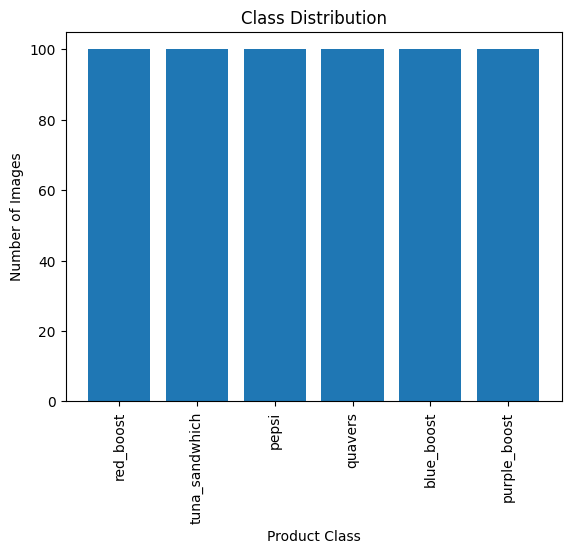

In [2]:
print("\n 1. CLASS DISTRIBUTION")

class_counts = {}

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

df_classes = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image_Count'])
df_classes = df_classes.sort_values(by='Image_Count', ascending=False)

print(df_classes)

# Plot
plt.figure()
plt.bar(df_classes['Class'], df_classes['Image_Count'])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Product Class")
plt.ylabel("Number of Images")
plt.show()

2. Image Resolution Analysis

Examines the variation in image dimensions across the dataset. This helps determine preprocessing needs, as inconsistent resolutions affect model performance and inference efficiency.


 2. IMAGE RESOLUTION ANALYSIS
Average Width: 3024.00
Average Height: 4032.00


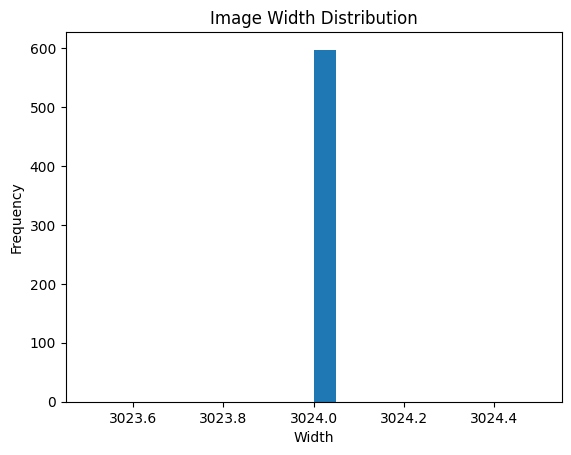

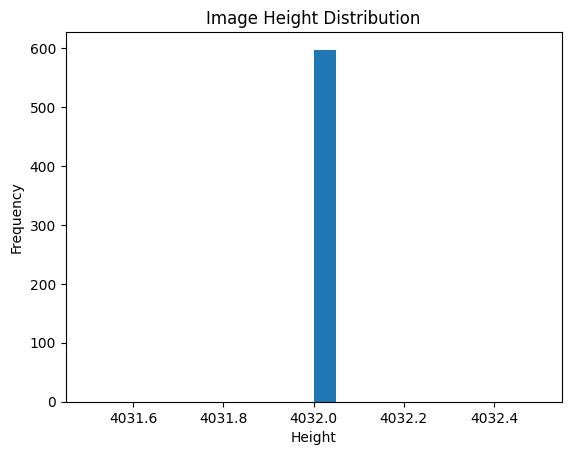

In [3]:
print("\n 2. IMAGE RESOLUTION ANALYSIS")

widths = []
heights = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                continue

print(f"Average Width: {np.mean(widths):.2f}")
print(f"Average Height: {np.mean(heights):.2f}")

# Plot Width
plt.figure()
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

# Plot Height
plt.figure()
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()


3. Brightness / Lighting Analysis

Measures pixel intensity to quantify illumination conditions in images. This is essential for analysing how lighting variations impact model robustness and classification accuracy.


 3. BRIGHTNESS / LIGHTING ANALYSIS
Average Brightness: 154.03
Min Brightness: 120.94
Max Brightness: 181.14


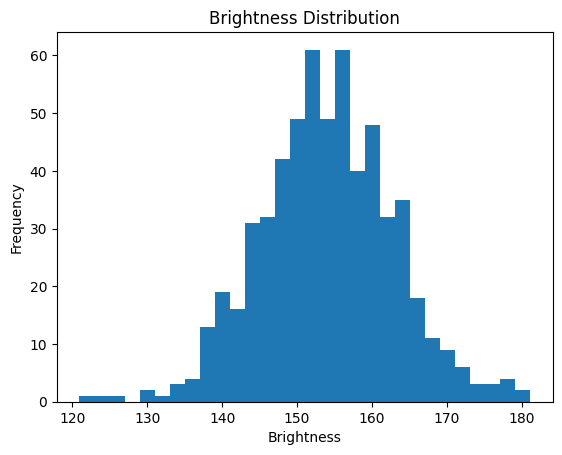

In [4]:
print("\n 3. BRIGHTNESS / LIGHTING ANALYSIS")

brightness_values = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            
            try:
                img = cv2.imread(img_path)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                brightness = np.mean(gray)
                brightness_values.append(brightness)
            except:
                continue

print(f"Average Brightness: {np.mean(brightness_values):.2f}")
print(f"Min Brightness: {np.min(brightness_values):.2f}")
print(f"Max Brightness: {np.max(brightness_values):.2f}")

# Plot
plt.figure()
plt.hist(brightness_values, bins=30)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()


4. RGB Channel Analysis

Evaluates the distribution of color channels across images. This helps identify color biases that may influence model predictions, especially under varying lighting conditions.


 4. RGB CHANNEL ANALYSIS
Mean R: 156.53
Mean G: 154.05
Mean B: 147.37


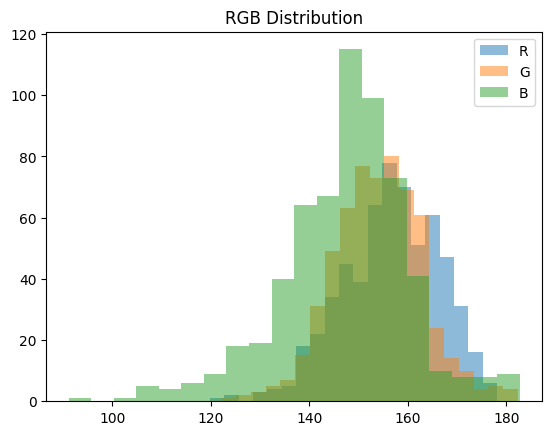

In [5]:
print("\n 4. RGB CHANNEL ANALYSIS")

r_vals, g_vals, b_vals = [], [], []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            
            try:
                img = cv2.imread(img_path)
                r_vals.append(np.mean(img[:,:,2]))
                g_vals.append(np.mean(img[:,:,1]))
                b_vals.append(np.mean(img[:,:,0]))
            except:
                continue

print(f"Mean R: {np.mean(r_vals):.2f}")
print(f"Mean G: {np.mean(g_vals):.2f}")
print(f"Mean B: {np.mean(b_vals):.2f}")

# Plot
plt.figure()
plt.hist(r_vals, bins=20, alpha=0.5, label='R')
plt.hist(g_vals, bins=20, alpha=0.5, label='G')
plt.hist(b_vals, bins=20, alpha=0.5, label='B')
plt.legend()
plt.title("RGB Distribution")
plt.show()


5. Sample Image Visualization

Displays representative images from different classes for qualitative inspection. This helps understand visual variability, background noise, and inter-class similarity affecting model learning.


 5. SAMPLE IMAGES


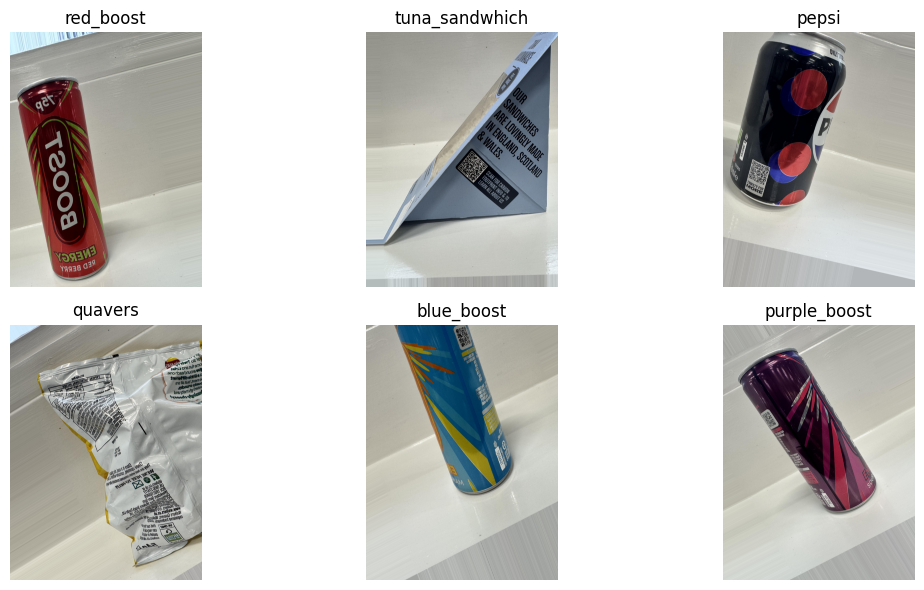

In [6]:
print("\n 5. SAMPLE IMAGES")

sample_images = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        if images:
            sample_images.append(os.path.join(class_path, random.choice(images)))

plt.figure(figsize=(12,6))

for i, img_path in enumerate(sample_images[:6]):
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(img_path)))
    plt.axis('off')

plt.tight_layout()
plt.show()


6. Lighting Category Split (Dark / Dim / Bright)

Groups images into discrete lighting conditions based on brightness thresholds. This enables controlled experimentation to evaluate model performance under different illumination scenarios.


⚡ 6. LIGHTING CATEGORY ANALYSIS
Dark Images: 0
Dim Images: 181
Bright Images: 416


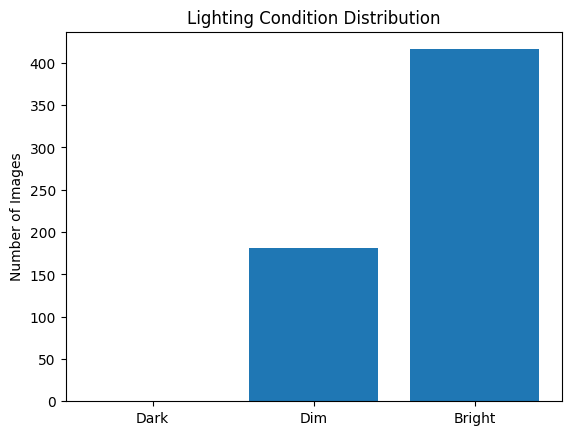


 EDA Completed Successfully


In [7]:
print("\n⚡ 6. LIGHTING CATEGORY ANALYSIS")

dark, dim, bright = 0, 0, 0

for val in brightness_values:
    if val < 50:
        dark += 1
    elif val < 150:
        dim += 1
    else:
        bright += 1

print(f"Dark Images: {dark}")
print(f"Dim Images: {dim}")
print(f"Bright Images: {bright}")

# Plot
labels = ['Dark', 'Dim', 'Bright']
values = [dark, dim, bright]

plt.figure()
plt.bar(labels, values)
plt.title("Lighting Condition Distribution")
plt.ylabel("Number of Images")
plt.show()

print("\n EDA Completed Successfully")